# Global YouTube Statistics: Data Analysis, Visualization, and Insights

In [50]:
#Import Libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [51]:
#Load DataSet
df = pd.read_csv("Global YouTube Statistics.csv" , encoding="latin1")

In [3]:
df.head()

,rank,Youtuber,subscribers,video views,category,Title,uploads,Country,Abbreviation,channel_type,...,subscribers_for_last_30_days,created_year,created_month,created_date,Gross tertiary education enrollment (%),Population,Unemployment rate,Urban_population,Latitude,Longitude
0,1,T-Series,245000000,2.280000e+11,Music,T-Series,20082,India,IN,Music,...,2000000.0,2006.0,Mar,13.0,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880
1,2,YouTube Movies,170000000,0.000000e+00,Film & Animation,youtubemovies,1,United States,US,Games,...,NaN,2006.0,Mar,5.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
2,3,MrBeast,166000000,2.836884e+10,Entertainment,MrBeast,741,United States,US,Entertainment,...,8000000.0,2012.0,Feb,20.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
3,4,Cocomelon - Nursery Rhymes,162000000,1.640000e+11,Education,Cocomelon - Nursery Rhymes,966,United States,US,Education,...,1000000.0,2006.0,Sep,1.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
4,5,SET India,159000000,1.480000e+11,Shows,SET India,116536,India,IN,Entertainment,...,1000000.0,2006.0,Sep,20.0,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880


In [4]:
df.shape

(995, 28)

In [52]:
#Data Exploration
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 995 entries, 0 to 994
Data columns (total 28 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   rank                                     995 non-null    int64  
 1   Youtuber                                 995 non-null    str    
 2   subscribers                              995 non-null    int64  
 3   video views                              995 non-null    float64
 4   category                                 949 non-null    str    
 5   Title                                    995 non-null    str    
 6   uploads                                  995 non-null    int64  
 7   Country                                  873 non-null    str    
 8   Abbreviation                             873 non-null    str    
 9   channel_type                             965 non-null    str    
 10  video_views_rank                         994 non-null    floa

In [6]:
df.columns

Index(['rank', 'Youtuber', 'subscribers', 'video views', 'category', 'Title',
       'uploads', 'Country', 'Abbreviation', 'channel_type',
       'video_views_rank', 'country_rank', 'channel_type_rank',
       'video_views_for_the_last_30_days', 'lowest_monthly_earnings',
       'highest_monthly_earnings', 'lowest_yearly_earnings',
       'highest_yearly_earnings', 'subscribers_for_last_30_days',
       'created_year', 'created_month', 'created_date',
       'Gross tertiary education enrollment (%)', 'Population',
       'Unemployment rate', 'Urban_population', 'Latitude', 'Longitude'],
      dtype='str')

In [7]:
#Data Cleaning. 

df.isnull().sum()

rank                                         0
Youtuber                                     0
subscribers                                  0
video views                                  0
category                                    46
Title                                        0
uploads                                      0
Country                                    122
Abbreviation                               122
channel_type                                30
video_views_rank                             1
country_rank                               116
channel_type_rank                           33
video_views_for_the_last_30_days            56
lowest_monthly_earnings                      0
highest_monthly_earnings                     0
lowest_yearly_earnings                       0
highest_yearly_earnings                      0
subscribers_for_last_30_days               337
created_year                                 5
created_month                                5
created_date 

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df['category'] = df['category'].fillna('Unknown')
df['Country'] = df['Country'].fillna('Unknown')
df['channel_type'] = df['channel_type'].fillna('Unknown')
df['country_rank'] = df['country_rank'].fillna(df['country_rank'].median())
df['channel_type_rank'] = df['channel_type_rank'].fillna(df['channel_type_rank'].median())
df['Population'] = df['Population'].fillna(df['Population'].median())
df = df.dropna(subset=['created_year'])
df = df.dropna(subset=['video_views_rank'])

In [12]:
df.dtypes

rank                                         int64
Youtuber                                       str
subscribers                                  int64
video views                                float64
category                                       str
Title                                          str
uploads                                      int64
Country                                        str
Abbreviation                                   str
channel_type                                   str
video_views_rank                           float64
country_rank                               float64
channel_type_rank                          float64
video_views_for_the_last_30_days           float64
lowest_monthly_earnings                    float64
highest_monthly_earnings                   float64
lowest_yearly_earnings                     float64
highest_yearly_earnings                    float64
subscribers_for_last_30_days               float64
created_year                   

In [13]:
df['Country'].value_counts().head(10)

Country
United States     312
India             168
Unknown           120
Brazil             61
United Kingdom     43
Mexico             33
Indonesia          28
Spain              22
Thailand           18
South Korea        17
Name: count, dtype: int64

In [15]:
#now removing unknown countries from the list 

top_countries = (df[df['Country'] != 'Unknown']['Country'].value_counts().head(10))

In [16]:
top_countries

Country
United States     312
India             168
Brazil             61
United Kingdom     43
Mexico             33
Indonesia          28
Spain              22
Thailand           18
South Korea        17
Russia             16
Name: count, dtype: int64

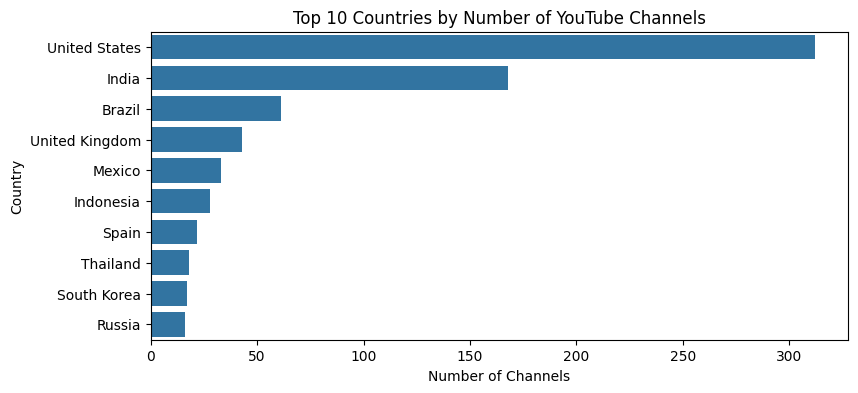

In [49]:
#Data Visualization 
plt.figure(figsize=(9,4))

sns.barplot(x = top_countries.values , y = top_countries.index)
plt.title('Top 10 Countries by Number of YouTube Channels')
plt.xlabel('Number of Channels')
plt.ylabel('Country')
plt.savefig('top_10_countries.png', bbox_inches='tight')
plt.show()

The United States has the highest number of YouTube channels in the dataset, followed by India and Brazil.
This indicates a strong creator presence in these countries.

In [20]:
df['category'].value_counts() 

category
Entertainment            240
Music                    200
People & Blogs           131
Gaming                    93
Comedy                    69
Film & Animation          46
Unknown                   46
Education                 45
Howto & Style             40
News & Politics           26
Science & Technology      17
Shows                     13
Sports                    11
Pets & Animals             4
Trailers                   2
Nonprofits & Activism      2
Movies                     2
Autos & Vehicles           2
Travel & Events            1
Name: count, dtype: int64

In [21]:
top_categories = ( df[df['category'] != 'Unknown']['category'].value_counts().head(10))

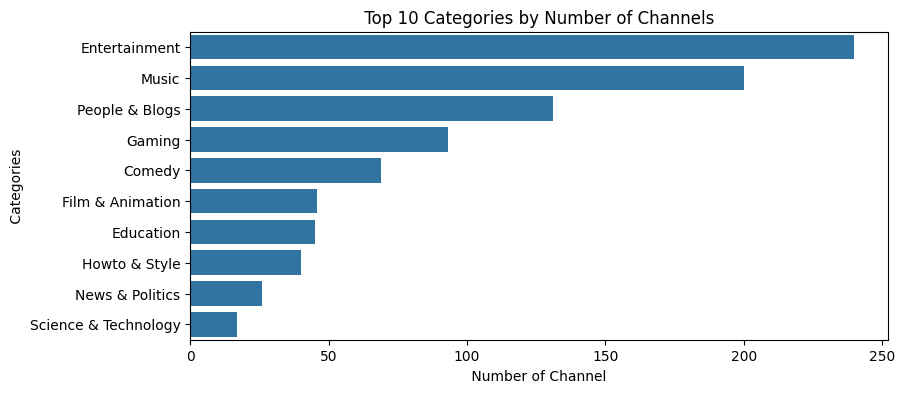

In [53]:
plt.figure(figsize=(9,4))
sns.barplot(x = top_categories.values , y = top_categories.index )
plt.xlabel(' Number of Channel ')
plt.ylabel(' Categories ')
plt.title(' Top 10 Categories by Number of Channels ')
plt.savefig('top_10_categories.png', bbox_inches='tight')
plt.show()

In [24]:
df['channel_type'].value_counts().head(10)

channel_type
Entertainment    304
Music            215
People           101
Games             97
Comedy            51
Education         49
Film              42
Howto             36
News              30
Unknown           27
Name: count, dtype: int64

In [25]:
top_channel_types = (df[df['channel_type'] != 'Unknown']['channel_type'].value_counts())

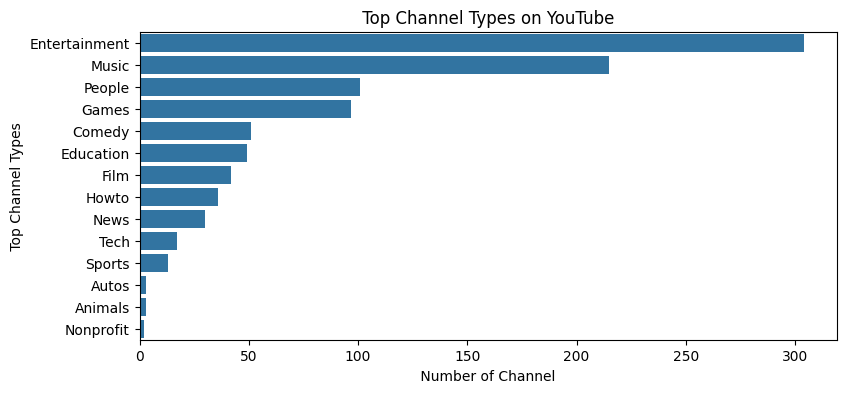

In [54]:
plt.figure(figsize=(9,4))
sns.barplot(x = top_channel_types.values , y = top_channel_types.index )
plt.xlabel(' Number of Channel ')
plt.ylabel(' Top Channel Types ')
plt.title(' Top Channel Types on YouTube ')
plt.savefig('top_channel_types.png', bbox_inches='tight')
plt.show()

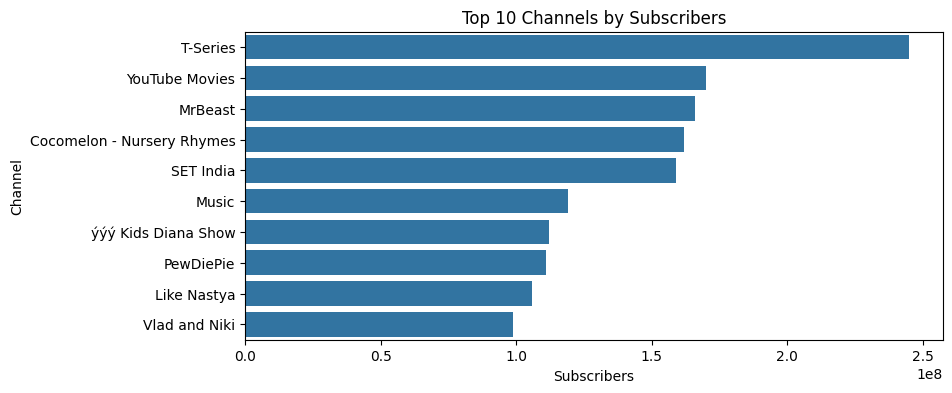

In [55]:
top_channels = df.nlargest(10, 'subscribers')
plt.figure(figsize=(9,4))

sns.barplot(x='subscribers', y='Youtuber', data=top_channels)

plt.title('Top 10 Channels by Subscribers')
plt.xlabel('Subscribers')
plt.ylabel('Channel')

plt.savefig('top_10_channels_subscribers.png', bbox_inches='tight') 
plt.show()                                                          

In [37]:
top_channels.shape

(10, 28)

In [39]:
#Top Countries by Total Subscribers

country_subscribers = (df[df['Country'] != 'Unknown'].groupby('Country')['subscribers'].sum().sort_values(ascending=False).head(10))

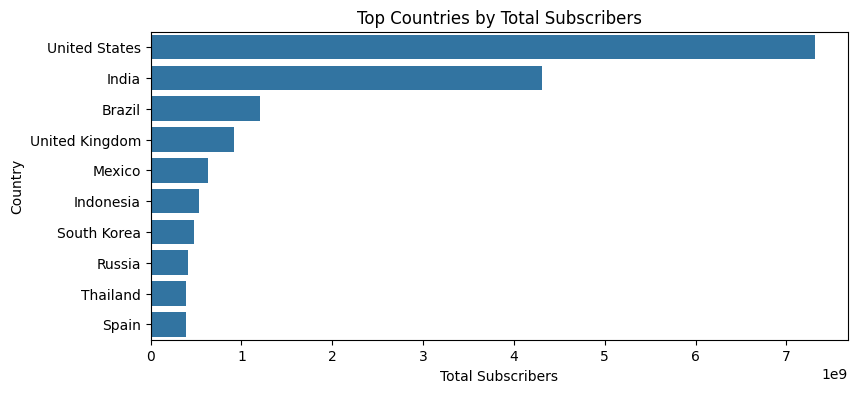

In [56]:
plt.figure(figsize=(9,4))
sns.barplot(x = country_subscribers.values , y=country_subscribers.index)
plt.title('Top Countries by Total Subscribers')
plt.xlabel('Total Subscribers')
plt.ylabel('Country')
plt.savefig('top_countries_total_subscribers.png', bbox_inches='tight')
plt.show()

Countries such as the United States and India contribute the largest share of subscribers.

In [42]:
#Channel Creation Trend by Year

creation_trend = (df['created_year'].value_counts().sort_index())

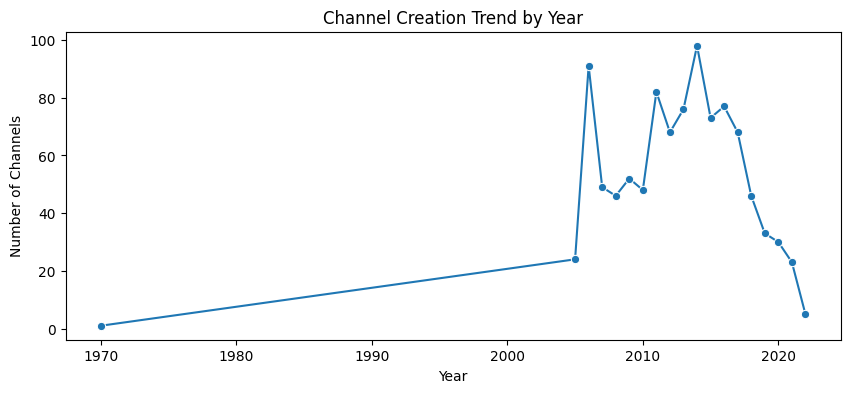

In [57]:
plt.figure(figsize=(10,4))
sns.lineplot(x = creation_trend.index , y = creation_trend.values , marker = 'o')

plt.title('Channel Creation Trend by Year')
plt.xlabel('Year')
plt.ylabel('Number of Channels')
plt.savefig('channel_creation_trend.png', bbox_inches='tight')
plt.show()

The number of successful YouTube channels increased significantly during YouTube's growth years,
indicating rising creator adoption over time.

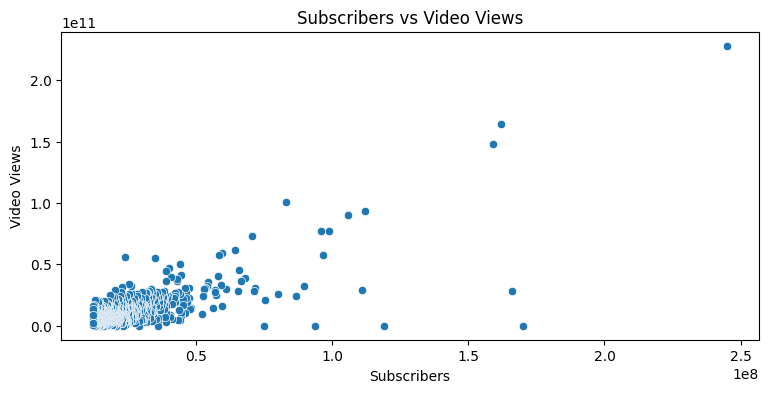

In [58]:
plt.figure(figsize=(9,4))

sns.scatterplot(
    x='subscribers',
    y='video views',
    data=df
)

plt.title('Subscribers vs Video Views')
plt.xlabel('Subscribers')
plt.ylabel('Video Views')
plt.savefig('subscribers_vs_video_views.png', bbox_inches='tight')
plt.show()

Channels with higher subscriber counts tend to have higher video views, indicating a positive relationship between audience size and content reach.

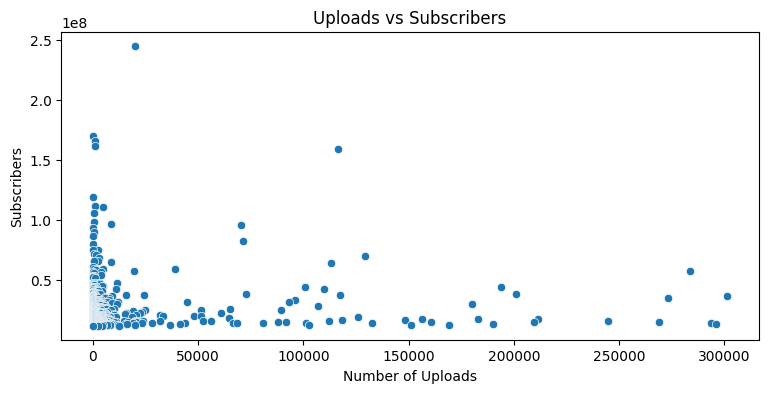

In [59]:
plt.figure(figsize=(9,4))

sns.scatterplot(x = 'uploads' , y = 'subscribers' , data=df)

plt.title('Uploads vs Subscribers')
plt.xlabel('Number of Uploads')
plt.ylabel('Subscribers')
plt.savefig('uploads_vs_subscribers.png', bbox_inches='tight')
plt.show()

The relationship between uploads and subscribers appears weak. While some channels with many uploads have large subscriber bases, 
uploading more videos does not necessarily guarantee higher subscriber counts

# Key Insights

1. Top 10 Countries by Number of Channels

The United States has the highest number of YouTube channels in the dataset, followed by India and Brazil. This indicates a strong creator presence and content production in these countries.

2. Top 10 Categories by Number of Channels

Entertainment and Music are among the most common categories, showing that these content types dominate YouTube and attract large audiences worldwide.

3. Top Channel Types on YouTube

Entertainment, Music, and People-related channels represent a significant portion of top YouTube channels, highlighting viewer interest in these content formats.

4. Top 10 Channels by Subscribers

A small number of channels hold exceptionally large subscriber bases, demonstrating that subscriber distribution on YouTube is highly concentrated among top creators.

5. Top Countries by Total Subscribers

The United States and India contribute the highest total subscriber counts, indicating their substantial influence on the global YouTube audience.

6. Channel Creation Trend by Year

The number of successful YouTube channels increased significantly over time, reflecting the platform's growth and increasing adoption by content creators.

7. Subscribers vs Video Views

Channels with higher subscriber counts generally tend to receive more video views. This suggests a positive relationship between audience size and content reach.

8. Uploads vs Subscribers

The relationship between uploads and subscribers appears relatively weak. While some channels with many uploads have large subscriber bases, uploading more videos alone does not guarantee subscriber growth.

# Conclusion

The analysis reveals that YouTube's ecosystem is dominated by a few highly influential channels and countries. 
Entertainment and Music content categories are the most prevalent among top channels. Subscriber count shows a strong association with video views, while upload frequency alone has a limited impact on subscriber growth. 
These insights help understand creator trends, audience behavior, and the factors contributing to channel success on YouTube.